In [49]:
# Setup notebook, and get paths 

from notebook_setup import setup
env = setup()

DATA_PATH = env["DATA_PATH"]
OUTPUT_PATH = env["OUTPUT_PATH"] / "05_plotting_energy_grids"
ANALYSIS_PATH_DFS = env["OUTPUT_PATH"] / "01_notebook_experiments" # path where dataframes from analysises are stored 
ANALYSIS_PATH_ENERGY_GRIDS = env["OUTPUT_PATH"] / "02_gnm_estimation" # path where energy grids are stored 

PREPROCESSED_PATH = env["PREPROCESSED_PATH"] / "01_first_analysises"

# create output path if it does not exist
if not OUTPUT_PATH.exists():
    OUTPUT_PATH.mkdir(parents=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/notebooks


In [77]:
print("So 4x4 took 44.96 seconds. How long does 100x100 take?")
in_seconds = 44.96 / 16**2 * 100**2
print("Seconds per 100x100 grid: ", in_seconds, "sec")
print("Minutes per 100x100 grid: ", int(in_seconds / 60) , "min and", int(in_seconds % 60), "sec")

So 4x4 took 44.96 seconds. How long does 100x100 take?
Seconds per 100x100 grid:  1756.25 sec
Minutes per 100x100 grid:  29 min and 16 sec


In [ ]:
import numpy as np
import scipy.io
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

# no need to add src, as src is added to path. 
from utils.saving_and_finding_files import time_stamp_for_saving, get_latest_file_name_of_data
from plotting.energy_landscape import plot_energy_landscape_from_df


# Plot heatmap of energy landscape from the latest GNM grid results

/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation/gnm_resolution68_etas100_gammas100_2025-08-13_18-54-34/preliminary_results/gnm_grid_partial_2025-08-13_18-54-34.csv


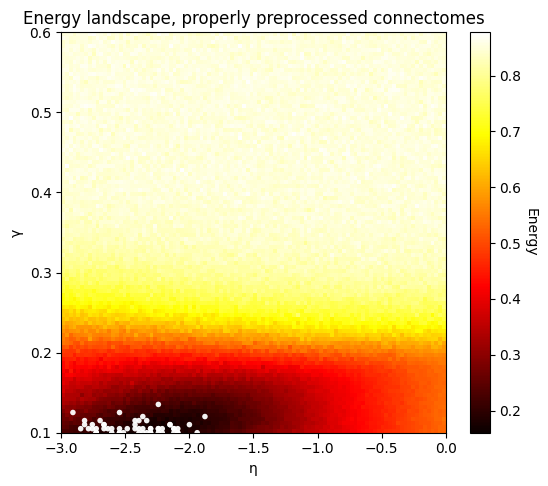

(<Figure size 620x520 with 2 Axes>,
 <Axes: title={'center': 'Energy landscape, properly preprocessed connectomes'}, xlabel='η', ylabel='γ'>)

In [78]:
from plotting.energy_landscape import plot_energy_landscape_from_df

# latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = get_latest_file_name_of_data("/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation", "gnm_grid_results_*.csv")
latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = get_latest_file_name_of_data(ANALYSIS_PATH_ENERGY_GRIDS, "gnm_grid_partial_*.csv")

print(latest_gnm_grid_results_path)

df = pd.read_csv(latest_gnm_grid_results_path)

plot_energy_landscape_from_df(df, dot_color="white", 
                              title="Energy landscape, properly preprocessed connectomes", 
                              interpolation="nearest", 
                              savepath=OUTPUT_PATH / f"energy_landscape_properly_preprocessed_connectomes_{latest_gnm_grid_results_timestamp}.png", 
                              show=True)


# Plotting other results

In [53]:
n = 68
bin_or_weighted = "all"  # or "bin"

graph_measures_empirical_connectomes = pd.read_csv(PREPROCESSED_PATH / f"df_graph_measures_{bin_or_weighted}_{n}_{n}.csv")
graph_measures_empirical_connectomes = graph_measures_empirical_connectomes.sort_values("network_index")
graph_measures_empirical_connectomes

,Unnamed: 0,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0,0.021013,0.597198,0.307704,0.610804,16.470588,0.513818,52.154297,1.911326,56,66.691791
1,1,1,0.021570,0.637913,0.215782,0.601557,19.529412,0.508043,55.586709,1.755487,62,61.192658
2,2,2,0.020930,0.607002,0.341498,0.628308,17.205882,0.519266,53.862432,1.872256,70,66.138129
3,3,3,0.020660,0.635426,0.285663,0.650042,20.029412,0.545131,57.407430,1.785338,76,71.637023
4,4,4,0.021431,0.621086,0.293950,0.603201,18.588235,0.530460,52.845603,1.828358,68,64.357605
...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,65,0.021095,0.621634,0.281932,0.601182,18.352941,0.507955,53.966299,1.818262,65,65.926942
66,66,66,0.020561,0.597381,0.341336,0.614537,16.500000,0.514720,51.526825,1.909131,63,62.647867
67,67,67,0.021183,0.613367,0.304807,0.607088,17.647059,0.514428,53.899209,1.846795,61,71.181777
68,68,68,0.021954,0.643986,0.245783,0.601241,20.441176,0.511276,55.465334,1.746708,63,62.986720


In [ ]:
# output = get_latest_file_name_of_data(ANALYSIS_PATH_ENERGY_GRIDS, "gnm_best_results_*.csv")
# if output is not None:
#     latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = output
#     best_gnm_per_subject = pd.read_csv(latest_gnm_grid_results_path)
# else: 
#     print("No best GNM results found.")

In [60]:
# latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = get_latest_file_name_of_data(ANALYSIS_PATH_ENERGY_GRIDS, "gnm_best_eval_*.csv")


# best_gnm_per_subject = pd.read_csv(latest_gnm_grid_results_path)
output = get_latest_file_name_of_data(ANALYSIS_PATH_ENERGY_GRIDS, "gnm_best_results_*.csv")
if output is not None:
    latest_gnm_grid_results_path, latest_gnm_grid_results_timestamp = output
    best_gnm_per_subject = pd.read_csv(latest_gnm_grid_results_path)
else: 
    print("No best GNM results found.")
    
    
# order by "subject" 
best_gnm_per_subject = best_gnm_per_subject.sort_values("subject")
best_gnm_per_subject

,subject,eta,gamma,energy,memory_capacity,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree_or_strength,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length,used_weighted_graph,treat_weights_as_lengths,min_weight_threshold,symmetrize
2,0,-2.0,0.1,0.147059,"{'mc_mean': 1.0480867347890503, 'mc_std': 0.00...",0,0.017356,0.463173,0.410594,0.426229,6.676471,0.327154,48.540625,2.529954,34,46.997088,True,False,0.0,max
10,1,-2.0,0.1,0.147059,"{'mc_mean': 1.0523670885339644, 'mc_std': 0.00...",0,0.015988,0.442853,0.436609,0.374001,6.676471,0.373609,44.266395,2.673077,38,51.875765,True,False,0.0,max
3,2,-2.0,0.1,0.176471,"{'mc_mean': 1.047713459186713, 'mc_std': 0.007...",0,0.017852,0.442196,0.426439,0.360652,6.676471,0.363951,45.368319,2.684615,32,41.373943,True,False,0.0,max
6,3,-2.0,0.1,0.191176,"{'mc_mean': 1.0528417165315291, 'mc_std': 0.00...",0,0.020316,0.443675,0.494052,0.387230,6.676471,0.337761,43.600604,2.630303,22,47.769055,True,False,0.0,max
0,4,-2.0,0.1,0.185022,"{'mc_mean': 1.0464305884688567, 'mc_std': 0.00...",0,0.019143,0.446535,0.407654,0.308599,6.676471,0.292412,45.553752,2.624709,23,39.723987,True,False,0.0,max
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,65,-2.0,0.1,0.162996,"{'mc_mean': 1.048895368907706, 'mc_std': 0.006...",0,0.016705,0.449415,0.396321,0.387620,6.676471,0.323928,44.329078,2.615385,40,52.282404,True,False,0.0,max
62,66,-3.0,0.1,0.147059,"{'mc_mean': 1.045809449926201, 'mc_std': 0.007...",0,0.018039,0.433540,0.548710,0.416790,6.676471,0.417132,35.284859,2.766865,32,35.188452,True,False,0.0,max
67,67,-2.0,0.1,0.191176,"{'mc_mean': 1.0556776883889425, 'mc_std': 0.00...",0,0.018056,0.436424,0.439296,0.386291,6.676471,0.354415,44.348853,2.711443,28,41.185474,True,False,0.0,max
68,68,-2.0,0.1,0.161765,"{'mc_mean': 1.048781601471147, 'mc_std': 0.008...",0,0.016763,0.439101,0.454705,0.380447,6.676471,0.415033,43.296453,2.780539,30,40.219412,True,False,0.0,max


In [61]:
memory_capacity = best_gnm_per_subject["memory_capacity"].values
print(f"Memory capacity: {memory_capacity}")

Memory capacity: ["{'mc_mean': 1.0480867347890503, 'mc_std': 0.005440668076876271}"
 "{'mc_mean': 1.0523670885339644, 'mc_std': 0.005580279621744162}"
 "{'mc_mean': 1.047713459186713, 'mc_std': 0.007070869554032796}"
 "{'mc_mean': 1.0528417165315291, 'mc_std': 0.00946515877335588}"
 "{'mc_mean': 1.0464305884688567, 'mc_std': 0.008577165701988566}"
 "{'mc_mean': 1.046779564235182, 'mc_std': 0.007282784048188767}"
 "{'mc_mean': 1.0443035588089826, 'mc_std': 0.00460662816634689}"
 "{'mc_mean': 1.0469202767201229, 'mc_std': 0.004844141774365418}"
 "{'mc_mean': 1.04308005783964, 'mc_std': 0.005397737057999242}"
 "{'mc_mean': 1.0493539823713383, 'mc_std': 0.007624293798038551}"
 "{'mc_mean': 1.0445026187427695, 'mc_std': 0.0065859608765144635}"
 "{'mc_mean': 1.0462477904381666, 'mc_std': 0.007626618470902341}"
 "{'mc_mean': 1.0487445229955183, 'mc_std': 0.005711623166410013}"
 "{'mc_mean': 1.0502121277533216, 'mc_std': 0.005291034057052052}"
 "{'mc_mean': 1.0516431450316372, 'mc_std': 0.0061

In [63]:
# SEQUENCE RECALL 
 
# mean_r2_sr = {}

# for subject in best_gnm_per_subject["sequence_recall"].values: 
#     # turn the string into a dict
#     subject = eval(subject)
#     # print(subject)
#     # print(subject.keys()) # dict keys 5,6,7,8,9,...,25 
#     for key in subject.keys():
#         if key not in mean_r2_sr:
#             mean_r2_sr[key] = []
#         mean_r2_sr[key].append(subject[key]["r2_mean"])

#     # print(subject[5])
#     # print(subject[5]["r2_mean"])

# len(mean_r2_sr[5])

In [64]:
# # get performance metric: Mean r2 over all lengths
# performances_mean_r2 = []
# for key in mean_r2_sr: 
#     one_subjects_performance_value = np.mean(mean_r2_sr[key])
#     performances_mean_r2.append(one_subjects_performance_value)
# print(performances_mean_r2)

In [65]:
# plt.plot(performances_mean_r2, color="blue")


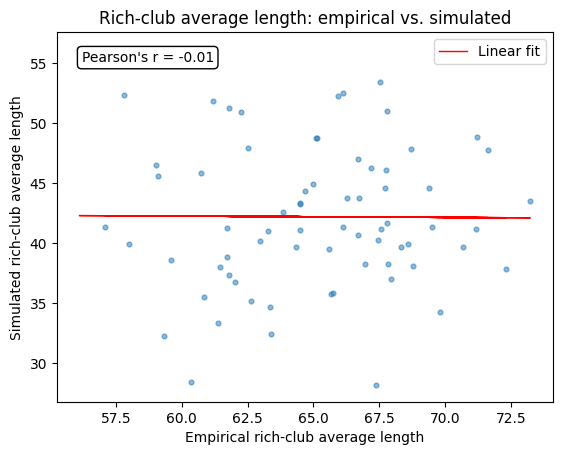

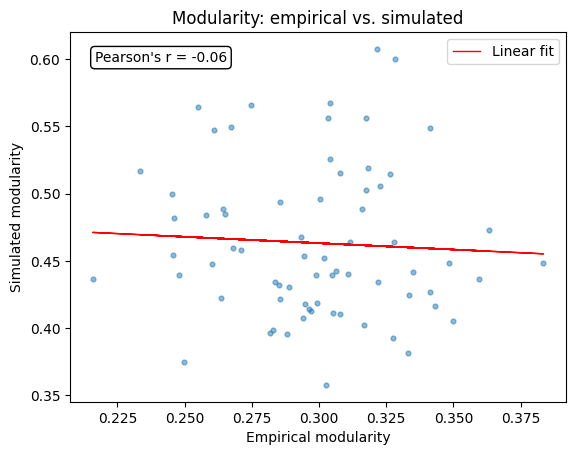

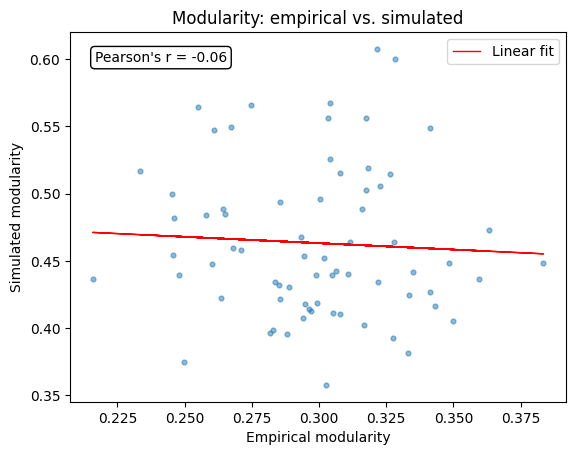

In [70]:
# variable_name = "richclub_avg_length"
from plotting.graphical_measures_measured_vs_simulated import plot_graph_measure_vs_simulated

variable_name = "richclub_avg_length"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

variable_name = "modularity"
plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name)

# plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name, color_metric=mean_r2_sr[6], color_metric_name="Mean R2 (Sequence Recall 6)")

plot_graph_measure_vs_simulated(graph_measures_empirical_connectomes, best_gnm_per_subject, variable_name) # , color_metric_name="Mean R2 (Sequence Recall 6)")
